# Project FORESIGHT — 02: Data Cleaning & Exploratory Data Analysis (EDA)

## Objective
This notebook performs data cleaning, feature engineering, and exploratory data analysis for **Project FORESIGHT**.

In accordance with the project architecture guidelines:
1. **Data Loading**: Load raw data from `data/`.
2. **Data Cleaning**: Handle missing values, filter unmonitored SKUs, and format dates.
3. **Feature Engineering**: Construct derived columns required for downstream modeling.
4. **Data Output**: Save the clean and processed datasets to `data/processed/`.
5. **EDA**: Visualize key trends, seasonality, and inventory patterns.

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data' if os.path.exists('../data') else 'data'
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f"Data directory resolved to: {os.path.abspath(DATA_DIR)}")
print(f"Processed directory resolved to: {os.path.abspath(PROCESSED_DIR)}")

Data directory resolved to: c:\Users\Aksha\Downloads\Project-FORESIGHT-main\data
Processed directory resolved to: c:\Users\Aksha\Downloads\Project-FORESIGHT-main\data\processed


In [10]:
from IPython.display import display
# Load raw CSV files
df_calendar = pd.read_csv(os.path.join(DATA_DIR, 'calendar.csv'))
df_inventory = pd.read_csv(os.path.join(DATA_DIR, 'inventory_snapshots.csv'))
df_sales = pd.read_csv(os.path.join(DATA_DIR, 'sales_daily.csv'))
df_sku = pd.read_csv(os.path.join(DATA_DIR, 'sku_master.csv'))

print("Data successfully loaded!")

Data successfully loaded!


In [11]:
from IPython.display import display
# 1. Calendar Cleaning: Fill missing values and format dates
df_calendar['date'] = pd.to_datetime(df_calendar['date'])
df_calendar['holiday'] = df_calendar['holiday'].fillna('None')
df_calendar['promotion_event'] = df_calendar['promotion_event'].fillna('None')

# 2. Inventory Cleaning: Keep only monitored SKUs present in sku_master
df_inventory['Snapshot_Date'] = pd.to_datetime(df_inventory['Snapshot_Date'])
valid_skus = set(df_sku['SKU'].unique())
df_inventory = df_inventory[df_inventory['SKU'].isin(valid_skus)].copy()

# 3. Sales Cleaning: Format dates
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

print(f"Cleaned Inventory Snapshots Shape (filtered to {len(valid_skus)} SKUs): {df_inventory.shape}")

Cleaned Inventory Snapshots Shape (filtered to 50 SKUs): (1200, 8)


In [12]:
from IPython.display import display
# 1. Calendar Derived Columns
df_calendar['ISO_Week'] = df_calendar['date'].dt.isocalendar().week.astype(int)
df_calendar['Year_Week'] = df_calendar['date'].dt.strftime('%Y-W%V')

# 2. SKU Master Derived Columns
df_sku['Calculated_Gross_Margin'] = df_sku['Selling_Price'] - df_sku['Cost_Price']
df_sku['Gross_Margin_Pct'] = (df_sku['Calculated_Gross_Margin'] / df_sku['Selling_Price'] * 100).round(2)
df_sku['Is_Negative_Margin'] = (df_sku['Gross_Margin_Per_Unit'] < 0).astype(int)
df_sku['Price_Tier'] = pd.qcut(df_sku['Selling_Price'], q=3, labels=['Low', 'Medium', 'High'])

# 3. Sales Daily Derived Columns
df_sales['Year'] = df_sales['Date'].dt.year
df_sales['Month'] = df_sales['Date'].dt.month
df_sales['Day'] = df_sales['Date'].dt.day
df_sales['Day_of_Week'] = df_sales['Date'].dt.day_name()
df_sales['Is_Weekend'] = df_sales['Date'].dt.dayofweek.isin([5, 6]).astype(int)
df_sales['ISO_Week'] = df_sales['Date'].dt.isocalendar().week.astype(int)
df_sales['Year_Week'] = df_sales['Date'].dt.strftime('%Y-W%V')
df_sales['Calculated_Revenue'] = df_sales['Units_Sold'] * df_sales['Price']
df_sales['Is_Zero_Sales'] = (df_sales['Units_Sold'] == 0).astype(int)

# 4. Inventory Snapshots Derived Columns
df_inventory['Total_Pipeline_Stock'] = df_inventory['Current_Stock'] + df_inventory['On_Order']
df_inventory['Is_Below_Reorder_Point'] = (df_inventory['Current_Stock'] <= df_inventory['Reorder_Point']).astype(int)
df_inventory['Is_Below_Safety_Stock'] = (df_inventory['Current_Stock'] <= df_inventory['Safety_Stock']).astype(int)

def assign_stock_status(row):
    if row['Current_Stock'] <= row['Safety_Stock']:
        return 'Critical (<= Safety Stock)'
    elif row['Current_Stock'] <= row['Reorder_Point']:
        return 'Reorder Needed (<= Reorder Point)'
    else:
        return 'Healthy (> Reorder Point)'

df_inventory['Stock_Status'] = df_inventory.apply(assign_stock_status, axis=1)

print("Feature engineering complete!")

Feature engineering complete!


In [13]:
from IPython.display import display
df_calendar.to_csv(os.path.join(PROCESSED_DIR, 'processed_calendar.csv'), index=False)
df_sku.to_csv(os.path.join(PROCESSED_DIR, 'processed_sku.csv'), index=False)
df_sales.to_csv(os.path.join(PROCESSED_DIR, 'processed_sales.csv'), index=False)
df_inventory.to_csv(os.path.join(PROCESSED_DIR, 'processed_inventory.csv'), index=False)

print(f"Processed datasets saved to: {os.path.abspath(PROCESSED_DIR)}")

Processed datasets saved to: c:\Users\Aksha\Downloads\Project-FORESIGHT-main\data\processed


## Section 2: Exploratory Data Analysis (EDA)
Visualizing sales trends, top/slow-moving SKUs, and inventory patterns.

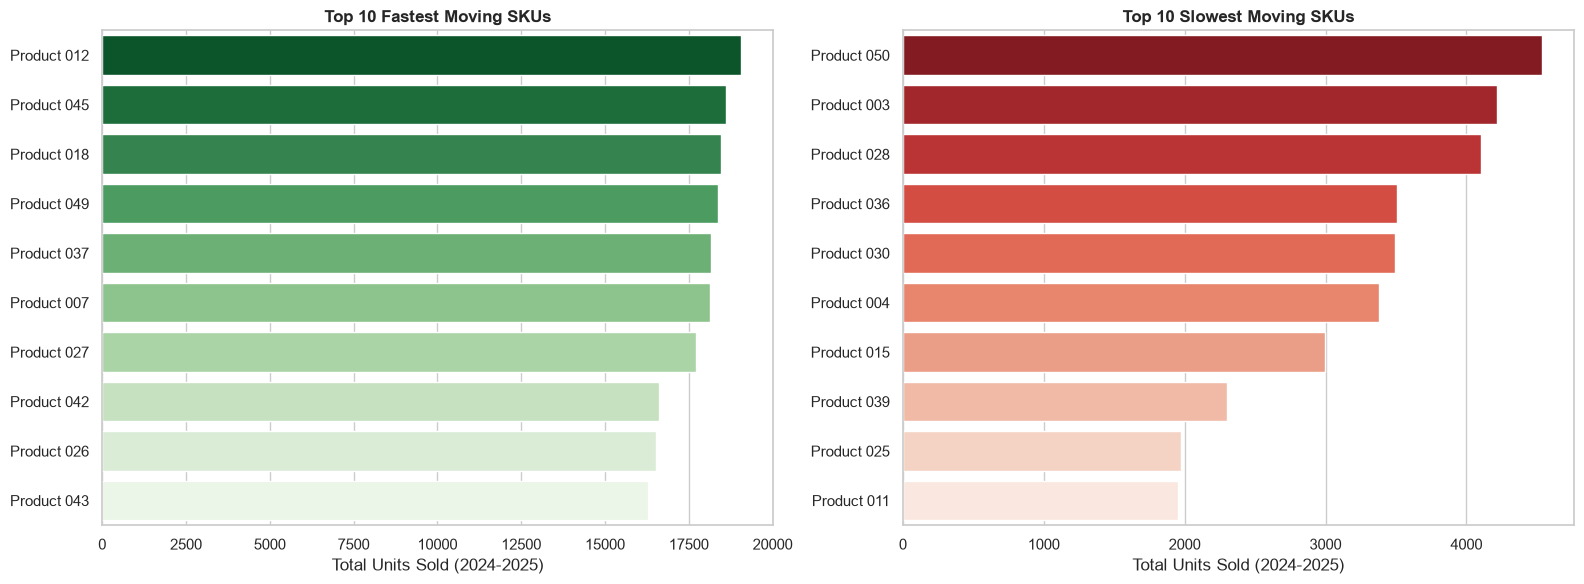

In [14]:
from IPython.display import display
# Calculate total units sold per SKU
sku_sales = df_sales.groupby('SKU')['Units_Sold'].sum().sort_values(ascending=False).reset_index()
sku_sales = sku_sales.merge(df_sku[['SKU', 'Product_Name', 'Category']], on='SKU', how='left')

top_10 = sku_sales.head(10)
bottom_10 = sku_sales.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_10, x='Units_Sold', y='Product_Name', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Fastest Moving SKUs', fontweight='bold')
axes[0].set_xlabel('Total Units Sold (2024-2025)')
axes[0].set_ylabel('')

sns.barplot(data=bottom_10, x='Units_Sold', y='Product_Name', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Slowest Moving SKUs', fontweight='bold')
axes[1].set_xlabel('Total Units Sold (2024-2025)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

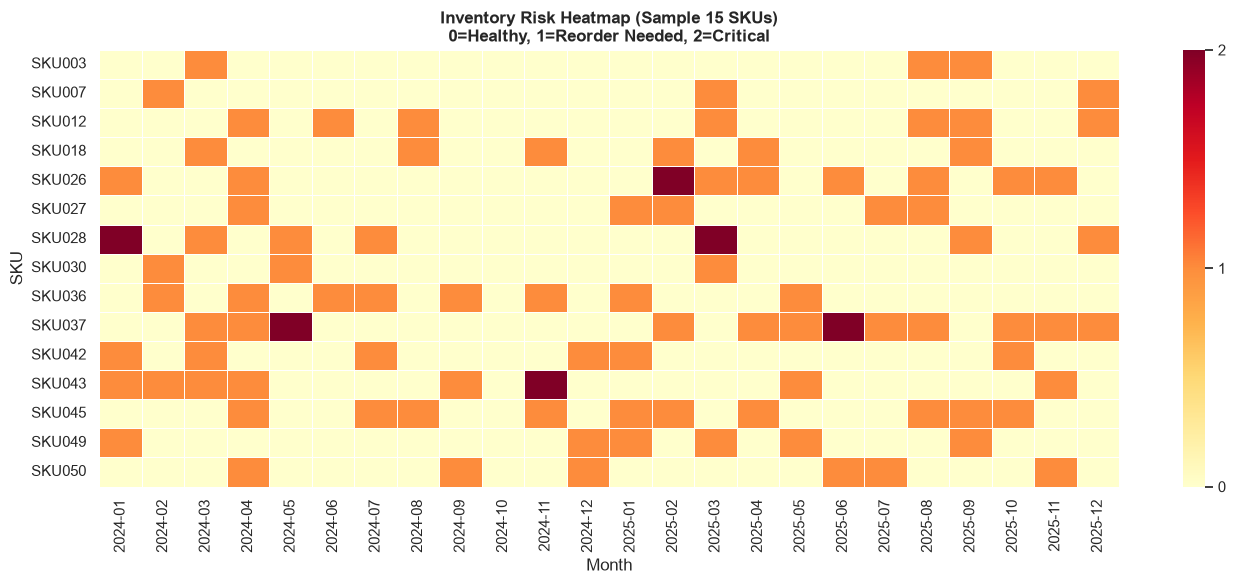

In [15]:
from IPython.display import display
# Inventory Stockouts/Reorders Heatmap across months (for top 15 SKUs to visualize)
top_15_skus = top_10['SKU'].tolist() + bottom_10['SKU'].head(5).tolist()
inv_sample = df_inventory[df_inventory['SKU'].isin(top_15_skus)]

# Map status to numbers: Healthy=0, Reorder Needed=1, Critical=2
status_map = {'Healthy (> Reorder Point)': 0, 'Reorder Needed (<= Reorder Point)': 1, 'Critical (<= Safety Stock)': 2}
inv_sample['Status_Score'] = inv_sample['Stock_Status'].map(status_map)

heatmap_data = inv_sample.pivot(index='SKU', columns='Snapshot_Date', values='Status_Score')
heatmap_data.columns = [col.strftime('%Y-%m') for col in heatmap_data.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'ticks': [0, 1, 2]}, linewidths=.5)
plt.title('Inventory Risk Heatmap (Sample 15 SKUs)\n0=Healthy, 1=Reorder Needed, 2=Critical', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('SKU')
plt.tight_layout()
plt.show()

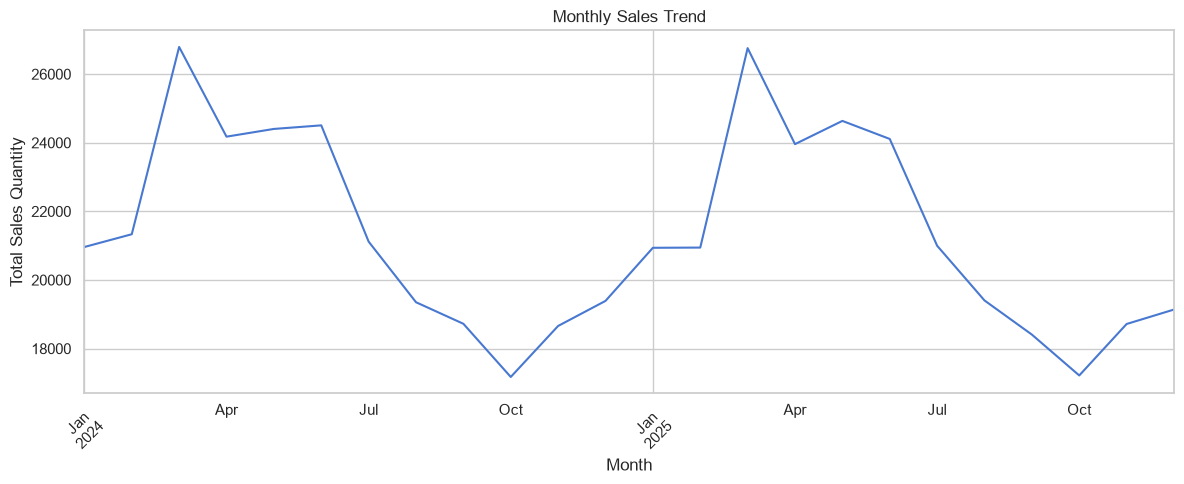

In [16]:
# Monthly Sales Trend

import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/processed/processed_sales.csv")

sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

monthly_sales = (
    sales.dropna(subset=["Date"])
    .set_index("Date")["Units_Sold"]
    .resample("ME")
    .sum()
)

plt.figure(figsize=(12, 5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

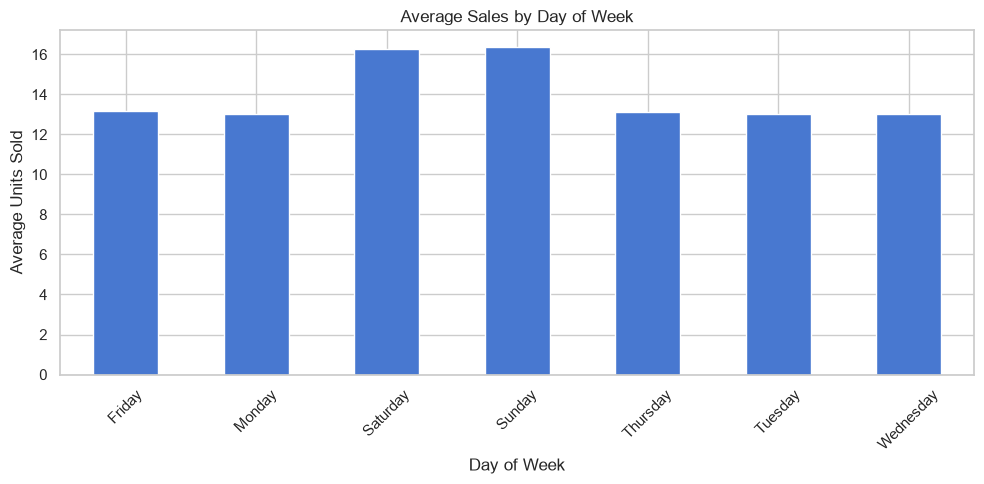

In [17]:
day_sales = (
    sales.groupby("Day_of_Week")["Units_Sold"]
    .mean()
)

plt.figure(figsize=(10, 5))
day_sales.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

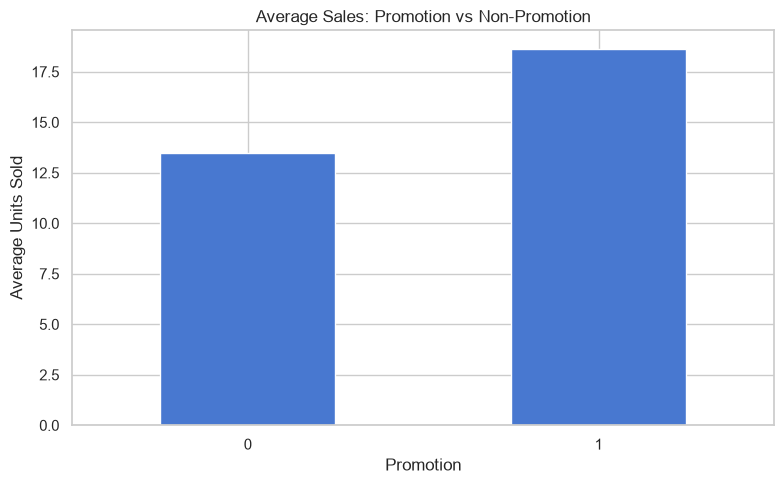

In [18]:
# Promotion Impact on Sales

promotion_sales = (
    sales.groupby("Promotion")["Units_Sold"]
    .mean()
)

plt.figure(figsize=(8, 5))
promotion_sales.plot(kind="bar")

plt.title("Average Sales: Promotion vs Non-Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

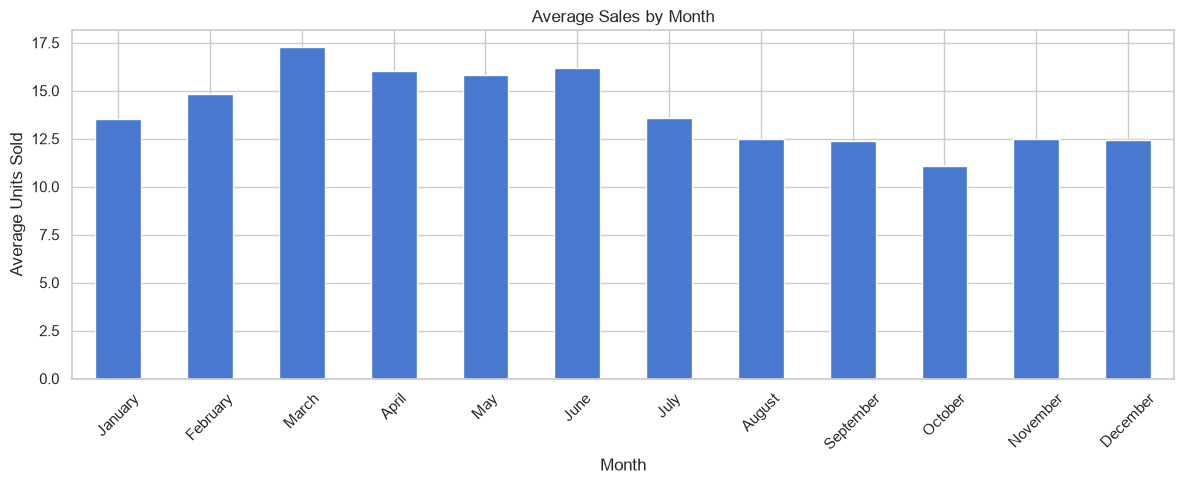

In [19]:
# Sales Seasonality by Month

sales["Month_Name"] = sales["Date"].dt.month_name()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_seasonality = (
    sales.groupby("Month_Name")["Units_Sold"]
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(12, 5))
monthly_seasonality.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

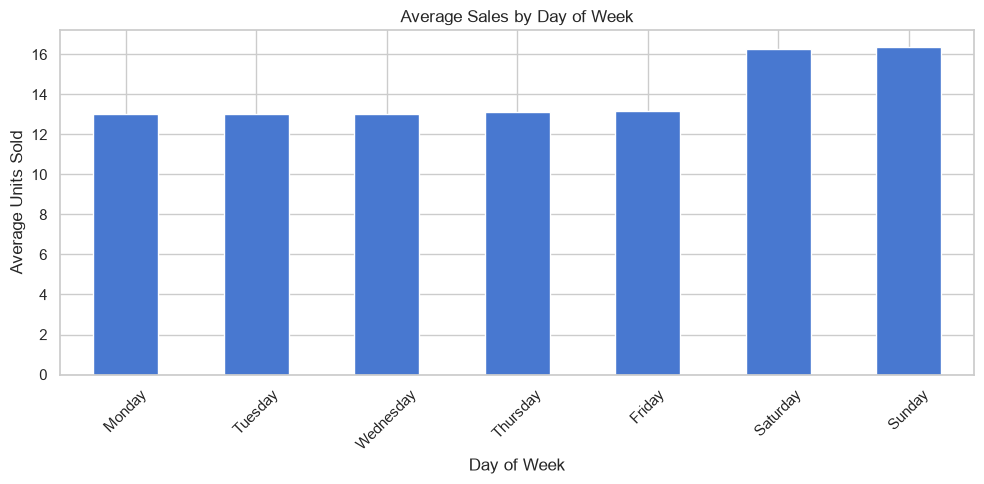

In [20]:
# Sales Seasonality by Day of Week

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_sales = (
    sales.groupby("Day_of_Week")["Units_Sold"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))
day_sales.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()